In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/Sample - Superstore.csv", encoding="latin1")

print(df.head())
print("\nDataset Shape:", df.shape)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [3]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by date
df = df.sort_values('Order Date')

# Group sales by month
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

# Convert period index to timestamp
monthly_sales.index = monthly_sales.index.to_timestamp()

# Display first few rows
print(monthly_sales.head())

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64


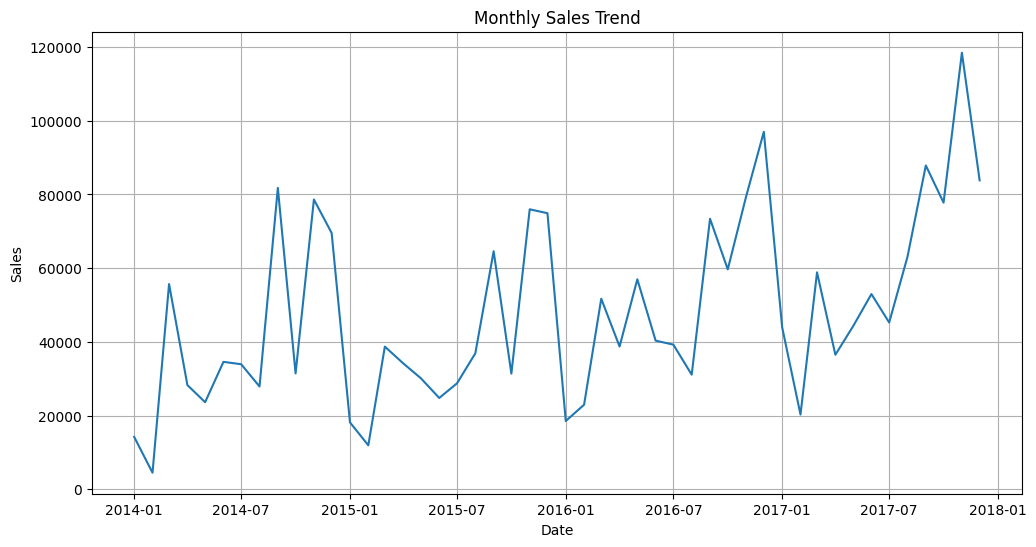

In [4]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [5]:
# Create time index
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Date', 'Sales']

monthly_sales_df['Month_Number'] = range(len(monthly_sales_df))

monthly_sales_df.head()

,Date,Sales,Month_Number
0,2014-01-01,14236.895,0
1,2014-02-01,4519.892,1
2,2014-03-01,55691.009,2
3,2014-04-01,28295.345,3
4,2014-05-01,23648.287,4


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = monthly_sales_df[['Month_Number']]
y = monthly_sales_df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 18041.64
RMSE: 23416.38


In [8]:
future_months = pd.DataFrame({
    'Month_Number': range(
        len(monthly_sales_df),
        len(monthly_sales_df) + 6
    )
})

future_predictions = model.predict(future_months)

print("Future Sales Forecast:")
print(future_predictions)

Future Sales Forecast:
[63485.5226372  64185.06924533 64884.61585346 65584.16246159
 66283.70906972 66983.25567785]


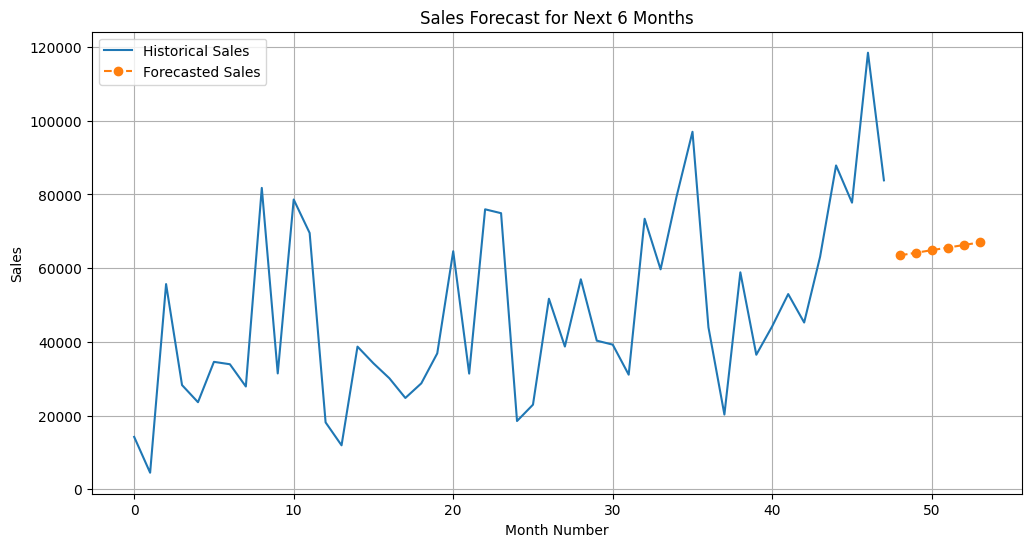

In [9]:
# Plot historical sales
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_df['Month_Number'],
    monthly_sales_df['Sales'],
    label='Historical Sales'
)

# Plot future forecast
future_x = future_months['Month_Number']

plt.plot(
    future_x,
    future_predictions,
    linestyle='--',
    marker='o',
    label='Forecasted Sales'
)

plt.title('Sales Forecast for Next 6 Months')
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.show()